In [ ]:
re
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Data Libraries
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load the Dataset
url = "/content/drive/My Drive/Colab Notebooks/uber_reviews_without_reviewid.csv"

df= pd.read_csv(url) # read local file

# Display first few rows of the dataset
print("Dataset Preview:")
print(df.head())

Dataset Preview:
  userName  userImage          content  score  thumbsUpCount  \
0   User_0        NaN             Good      5              0   
1   User_1        NaN             Nice      5              0   
2   User_2        NaN  Very convenient      5              0   
3   User_3        NaN             Good      4              0   
4   User_4        NaN         exllence      5              0   

  reviewCreatedVersion                   at replyContent repliedAt  \
0          4.556.10005  2024-12-18 17:17:19          NaN       NaN   
1          4.556.10005  2024-12-18 17:17:17          NaN       NaN   
2          4.532.10001  2024-12-18 17:09:42          NaN       NaN   
3          4.556.10005  2024-12-18 17:08:27          NaN       NaN   
4          4.556.10005  2024-12-18 17:08:16          NaN       NaN   

    appVersion  
0  4.556.10005  
1  4.556.10005  
2  4.532.10001  
3  4.556.10005  
4  4.556.10005  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


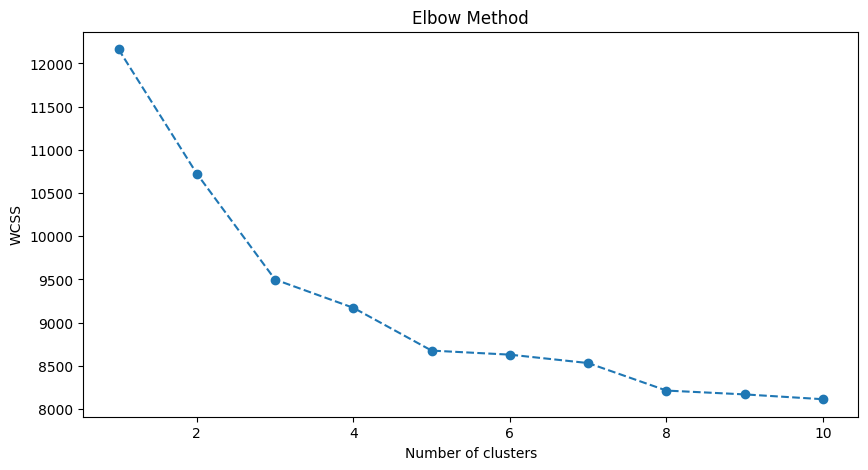

            score       content
             mean count   count
cluster                        
0        4.902463  6172    6172
1        4.841357  2181    2181
2        1.278003  3205    3205
3        4.959276   442     442


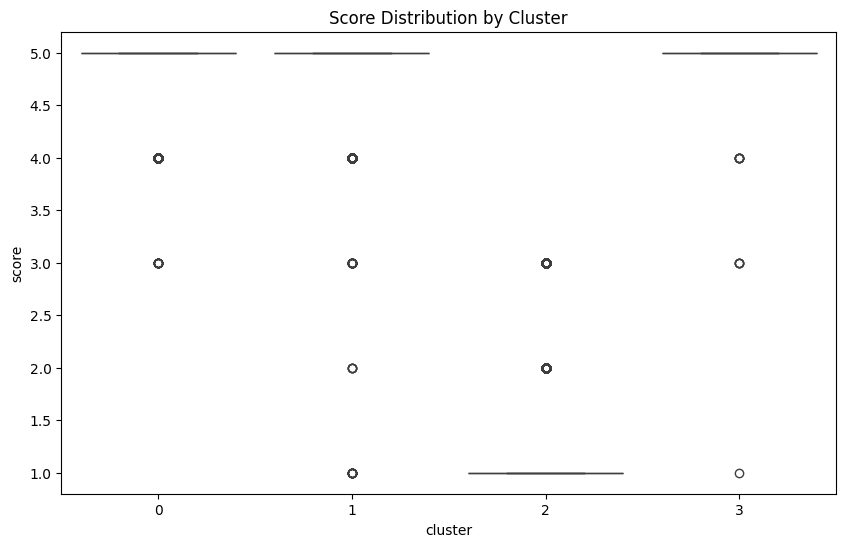

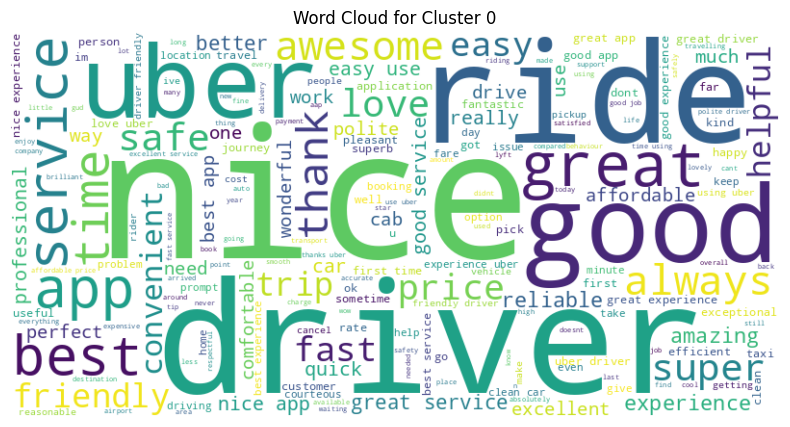

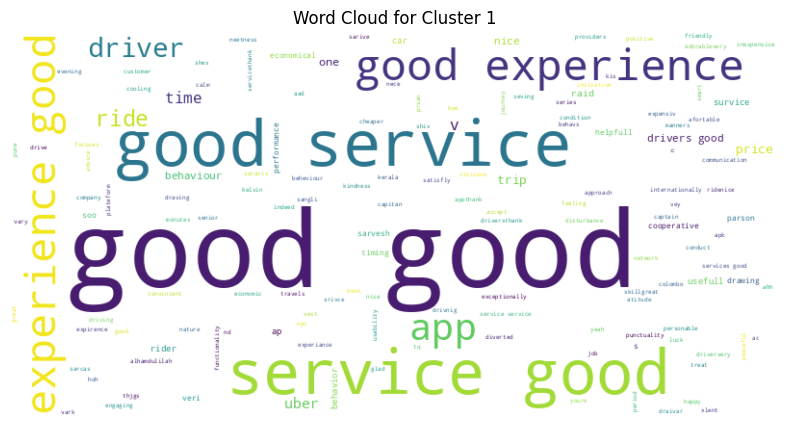

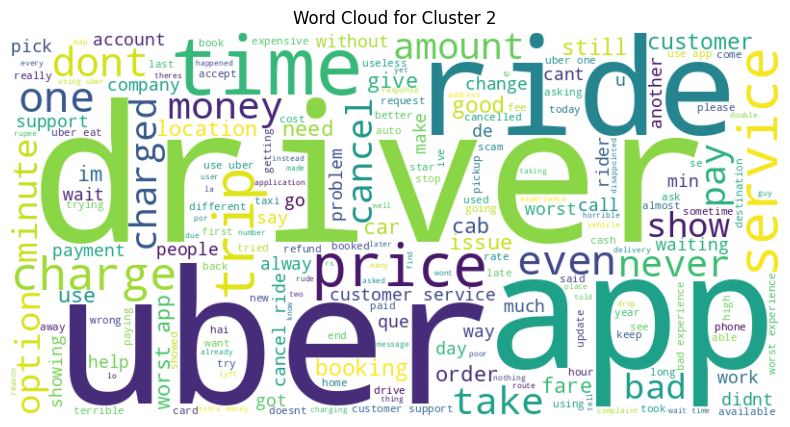

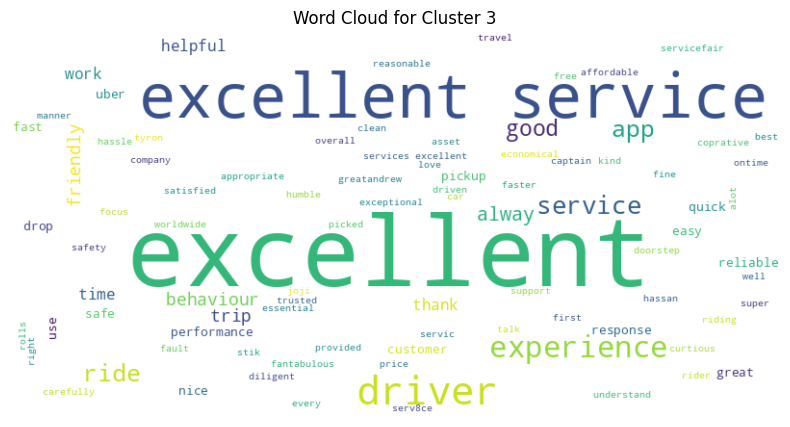

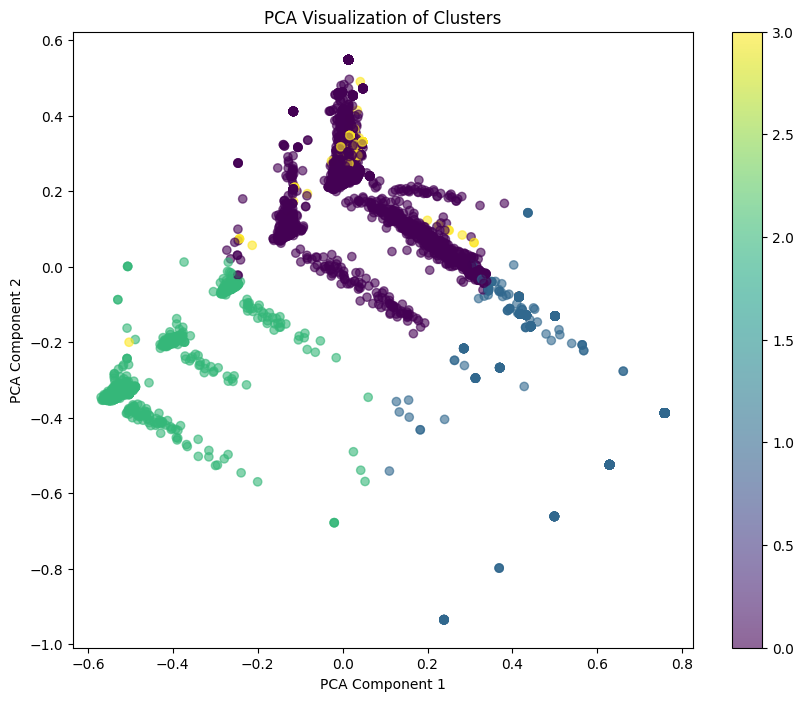


Marketing Strategy Recommendations:
1. Cluster 0: High satisfaction (avg rating: 4.9). Key terms: nice, good, great, uber, service. Strategy: Encourage referrals, feature in testimonials, offer loyalty rewards.
2. Cluster 1: High satisfaction (avg rating: 4.8). Key terms: good, service, experience, 👍, app. Strategy: Encourage referrals, feature in testimonials, offer loyalty rewards.
3. Cluster 2: Low satisfaction (avg rating: 1.3). Key terms: uber, app, ride, driver, drivers. Strategy: Address pain points, offer personalized support, provide recovery offers.
4. Cluster 3: High satisfaction (avg rating: 5.0). Key terms: excellent, service, driver, experience, 👌. Strategy: Encourage referrals, feature in testimonials, offer loyalty rewards.


In [ ]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from nltk.corpus import stopwords
import nltk
import string

# Download stopwords if not already present
nltk.download('stopwords')

# Step 2: Load and preprocess the data
# Assuming your data is in a CSV file named 'user_reviews.csv'
df = pd.read_csv(url)

# Keep only relevant columns
df = df[['userName', 'score', 'content']]

# Text preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

# Apply preprocessing
df['cleaned_content'] = df['content'].apply(preprocess_text)

# Step 3: Feature Engineering
# Create TF-IDF matrix for text content
vectorizer = TfidfVectorizer(max_features=1000)
X_text = vectorizer.fit_transform(df['cleaned_content'])

# Combine with numerical score (normalized)
X_score = df['score'].values.reshape(-1, 1) / 5  # Normalize to 0-1 range

# Combine features
from scipy.sparse import hstack
X = hstack([X_text, X_score])

# Step 4: Determine optimal number of clusters (Elbow Method)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Step 5: Apply K-means clustering (assuming 4 clusters based on elbow method)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X)

# Add cluster labels to dataframe
df['cluster'] = clusters

# Step 6: Analyze clusters
# Cluster statistics
cluster_stats = df.groupby('cluster').agg({
    'score': ['mean', 'count'],
    'content': 'count'
})
print(cluster_stats)

# Visualize score distribution per cluster
plt.figure(figsize=(10,6))
sns.boxplot(x='cluster', y='score', data=df)
plt.title('Score Distribution by Cluster')
plt.show()

# Step 7: Generate word clouds for each cluster
for cluster_num in range(n_clusters):
    cluster_text = ' '.join(df[df['cluster'] == cluster_num]['cleaned_content'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(cluster_text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for Cluster {cluster_num}')
    plt.axis('off')
    plt.show()

# Step 8: PCA for visualization (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(10,8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('PCA Visualization of Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter)
plt.show()

# Step 9: Marketing Strategy Suggestions
def generate_marketing_strategies(cluster_stats, df):
    strategies = []

    for cluster in range(n_clusters):
        cluster_data = df[df['cluster'] == cluster]
        avg_score = cluster_data['score'].mean()
        common_words = ' '.join(cluster_data['cleaned_content']).split()
        common_words = pd.Series(common_words).value_counts().head(5).index.tolist()

        if avg_score >= 4.5:
            strategy = (f"Cluster {cluster}: High satisfaction (avg rating: {avg_score:.1f}). "
                       f"Key terms: {', '.join(common_words)}. "
                       "Strategy: Encourage referrals, feature in testimonials, "
                       "offer loyalty rewards.")
        elif avg_score >= 3.5:
            strategy = (f"Cluster {cluster}: Moderate satisfaction (avg rating: {avg_score:.1f}). "
                       f"Key terms: {', '.join(common_words)}. "
                       "Strategy: Identify improvement areas, send satisfaction surveys, "
                       "offer targeted upgrades.")
        else:
            strategy = (f"Cluster {cluster}: Low satisfaction (avg rating: {avg_score:.1f}). "
                       f"Key terms: {', '.join(common_words)}. "
                       "Strategy: Address pain points, offer personalized support, "
                       "provide recovery offers.")

        strategies.append(strategy)

    return strategies

# Generate and print strategies
strategies = generate_marketing_strategies(cluster_stats, df)
print("\nMarketing Strategy Recommendations:")
for i, strategy in enumerate(strategies):
    print(f"{i+1}. {strategy}")

# Save processed data
df.to_csv("/content/drive/My Drive/Colab Notebooks/uber_reviews_cluster.csv", index=False)


In [ ]:
# Save processed data
df.to_csv("/content/drive/My Drive/Colab Notebooks/uber_reviews_cluster.csv", index=False)

In [ ]:
# Cluster 1 Version Analysis (English Version)
import pandas as pd

# 1. Reload original dataset with version info
try:
    original_df = pd.read_csv(url)  # Replace with your filename
    print("Original data loaded successfully")

    # 2. Verify version column exists
    if 'appVersion' not in original_df.columns:
        print("Error: 'appVersion' column missing in original data")
    else:
        # 3. Merge cluster labels from current analysis
        original_df['cluster'] = df['cluster']  # Assuming 'df' has your clusters

        # 4. Analyze Cluster 1 versions
        cluster1_versions = original_df.loc[original_df['cluster'] == 1, 'appVersion']

        if cluster1_versions.empty:
            print("No users in Cluster 1")
        else:
            # Basic version stats
            print("\n=== Cluster 1 Version Report ===")
            print("Top 5 versions:")
            print(cluster1_versions.value_counts().head().to_markdown())

            # Version performance
            version_stats = original_df[original_df['cluster'] == 1].groupby('appVersion').agg(
                avg_score=('score', 'mean'),
                user_count=('userName', 'count')
            ).sort_values('avg_score', ascending=False)

            print("\nBest performing versions:")
            print(version_stats.head(3).to_markdown())
except FileNotFoundError:
    print("Error: Original data file not found")
except Exception as e:
    print(f"Unexpected error: {str(e)}")
    #Modified version analysis (including rating)
cluster1_data = original_df[original_df['cluster'] == 1]
version_stats = cluster1_data.groupby('appVersion').agg(
    user_count=('userName', 'count'),
    avg_score=('score', 'mean'),
    score_std=('score', 'std')
).sort_values('user_count', ascending=False)

print("\n=== Version distribution and rating ===")
print(version_stats.head().to_markdown())


Original data loaded successfully

=== Cluster 1 Version Report ===
Top 5 versions:
| appVersion   |   count |
|:-------------|--------:|
| 4.554.10001  |     647 |
| 4.555.10003  |     431 |
| 4.556.10005  |     330 |
| 4.553.10000  |     288 |
| 4.552.10000  |      56 |

Best performing versions:
| appVersion   |   avg_score |   user_count |
|:-------------|------------:|-------------:|
| 4.293.10007  |           5 |            1 |
| 4.303.10002  |           5 |            1 |
| 4.337.10006  |           5 |            1 |

=== Version distribution and rating ===
| appVersion   |   user_count |   avg_score |   score_std |
|:-------------|-------------:|------------:|------------:|
| 4.554.10001  |          647 |     4.82071 |    0.511784 |
| 4.555.10003  |          431 |     4.84919 |    0.485121 |
| 4.556.10005  |          330 |     4.8697  |    0.402866 |
| 4.553.10000  |          288 |     4.85069 |    0.502883 |
| 4.552.10000  |           56 |     4.78571 |    0.706188 |
